# Experiment Results Analysis  

## BTC DCA Weight Optimization — V1 / V2 / V3 Model Comparison

**Experiment Overview:**
- **16 experiments** conducted (run_seq r001 – r016)
- **3 model versions**: V1 (Rule-based), V2 (Walk-forward Optimized), V3 (Q-Learning RL)
- **Polymarket overlay**: `+crypto+us_affairs` variant tested across V1/V2/V3
- **Evaluation metrics**: Score, Win Rate, Mean/Median Excess Percentile
- **Benchmark**: Performance vs. Uniform DCA (equal daily allocation)

**Analysis Structure:**
1. **V1 Analysis** — 8 variants (base + Polymarket overlay combinations)
2. **V2 Analysis** — 4 variants (default / optimized × base / +crypto+us_affairs)
3. **V3 Analysis** — 4 variants (Q-Learner / Inverse × base / +crypto+us_affairs)
4. **Cross-Model Comparison** — unified ranking, trade-off analysis, and conclusions

In [ ]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11

# Load run results
with open("./run_results.json") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)

# Clean numeric columns
numeric_cols = [
    "score", "win_rate", "wins", "losses", "total_windows",
    "mean_excess", "median_excess", "exp_decay_percentile",
    "mean_ratio", "median_ratio",
    "relative_improvement_pct_mean", "relative_improvement_pct_median",
]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed")

# Add poly overlay flag
df["has_poly"] = df["variant"].str.contains("crypto\\+us_affairs|crypto_us_affairs", regex=True, na=False)

print(f"Total experiments: {len(df)}")
print(f"Versions: {df['version'].unique().tolist()}")
print(f"Date range: {df['timestamp'].min().date()} -> {df['timestamp'].max().date()}")
df[["run_id", "version", "variant", "score", "win_rate", "mean_excess", "median_excess"]]

Total experiments: 12
Versions: ['v1', 'v2', 'v3']
Date range: 2026-04-04 -> 2026-04-04


,run_id,version,variant,score,win_rate,mean_excess,median_excess
0,v1_r001_base,v1,base,58.83,67.34,3.84,5.40
1,v1_r002_crypto,v1,base+crypto,58.73,67.93,3.36,4.88
2,v1_r003_trump,v1,base+trump,57.30,66.21,3.14,4.93
3,v1_r004_us_affairs,v1,base+us_affairs,58.24,67.38,3.53,5.56
4,v1_r005_crypto_us_affairs,v1,base+crypto+us_affairs,58.82,68.28,3.40,5.17
5,v1_r006_crypto_trump,v1,base+crypto+trump,58.19,67.46,3.25,4.97
6,v1_r007_trump_us_affairs,v1,base+trump+us_affairs,58.08,67.23,3.34,5.28
7,v1_r008_crypto_trump_us_affairs,v1,base+crypto+trump+us_affairs,58.38,67.70,3.33,5.08
8,v2_r009_optimized,v2,optimized,61.37,66.64,6.52,7.68
9,v2_r010_default,v2,default,58.87,67.42,3.86,5.44


In [15]:
# --- V1 Variants Ranking Table ---
v1 = df[df["version"] == "v1"].copy()
v1["n_poly_overlays"] = v1["variant"].apply(
    lambda x: 0 if x == "base" else x.replace("base+", "").count("+") + 1
)
v1_display = v1[["run_id", "variant", "score", "win_rate", "mean_excess",
                  "median_excess", "n_poly_overlays"]].sort_values("score", ascending=False)
v1_display = v1_display.reset_index(drop=True)
v1_display.index += 1
v1_display.index.name = "rank"
v1_display

,run_id,variant,score,win_rate,mean_excess,median_excess,n_poly_overlays
rank,,,,,,,
1,v1_r001_base,base,58.83,67.34,3.84,5.40,0
2,v1_r005_crypto_us_affairs,base+crypto+us_affairs,58.82,68.28,3.40,5.17,2
3,v1_r002_crypto,base+crypto,58.73,67.93,3.36,4.88,1
4,v1_r008_crypto_trump_us_affairs,base+crypto+trump+us_affairs,58.38,67.70,3.33,5.08,3
5,v1_r004_us_affairs,base+us_affairs,58.24,67.38,3.53,5.56,1
6,v1_r006_crypto_trump,base+crypto+trump,58.19,67.46,3.25,4.97,2
7,v1_r007_trump_us_affairs,base+trump+us_affairs,58.08,67.23,3.34,5.28,2
8,v1_r003_trump,base+trump,57.30,66.21,3.14,4.93,1


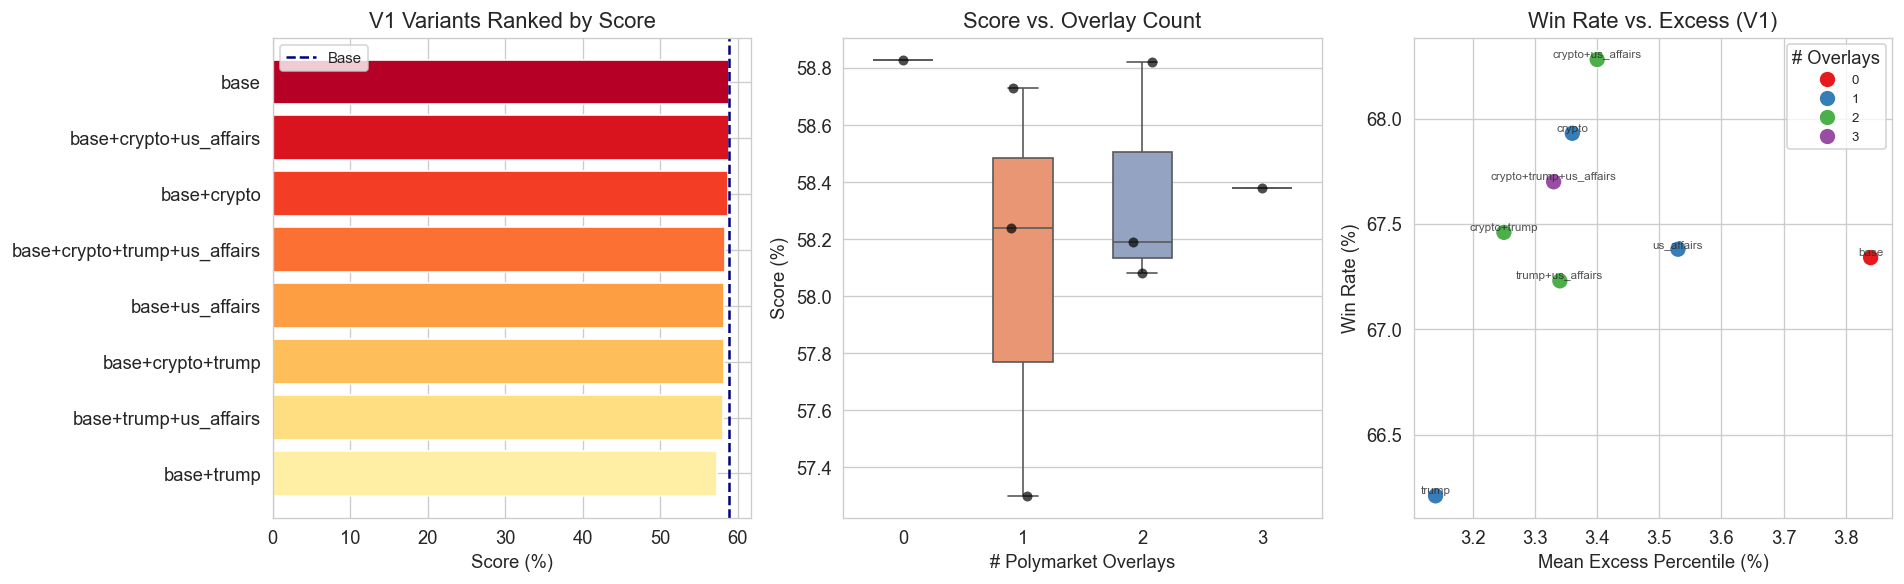

In [16]:
# --- V1: Score vs Number of Polymarket Overlays ---
v1 = df[df["version"] == "v1"].copy()
v1["n_poly_overlays"] = v1["variant"].apply(
    lambda x: 0 if x == "base" else x.replace("base+", "").count("+") + 1
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1a. Bar chart: All V1 variants ranked by score
v1_sorted = v1.sort_values("score", ascending=True)
colors = sns.color_palette("YlOrRd", n_colors=len(v1_sorted))
ax = axes[0]
bars = ax.barh(v1_sorted["variant"], v1_sorted["score"], color=colors)
ax.set_xlabel("Score (%)")
ax.set_title("V1 Variants Ranked by Score")
ax.axvline(v1.loc[v1["variant"] == "base", "score"].values[0],
           color="navy", ls="--", lw=1.5, label="Base")
ax.legend(fontsize=9)

# 1b. Box plot: Score by number of overlays
ax = axes[1]
sns.boxplot(data=v1, x="n_poly_overlays", y="score", ax=ax, palette="Set2", width=0.5)
sns.stripplot(data=v1, x="n_poly_overlays", y="score", ax=ax, color="black", size=6, alpha=0.7)
ax.set_xlabel("# Polymarket Overlays")
ax.set_ylabel("Score (%)")
ax.set_title("Score vs. Overlay Count")

# 1c. Scatter: Win Rate vs Mean Excess
ax = axes[2]
sns.scatterplot(data=v1, x="mean_excess", y="win_rate", hue="n_poly_overlays",
                palette="Set1", s=100, ax=ax, legend="full")
for _, row in v1.iterrows():
    label = row["variant"].replace("base+", "").replace("base", "base")
    ax.annotate(label, (row["mean_excess"], row["win_rate"]),
                fontsize=7, ha="center", va="bottom", alpha=0.8)
ax.set_xlabel("Mean Excess Percentile (%)")
ax.set_ylabel("Win Rate (%)")
ax.set_title("Win Rate vs. Excess (V1)")
ax.legend(title="# Overlays", fontsize=8)

plt.tight_layout()
plt.show()

### V1 Findings

**Observation 1: Base model achieves the highest score (58.83%).**
Adding Polymarket overlays never improves the overall score. The `base+crypto+us_affairs` variant ties at 58.82% but does not exceed it.

**Observation 2: Polymarket overlays introduce noise rather than signal.**
- The Trump index is the most harmful overlay (57.30% when added alone — the worst V1 variant)
- Crypto index has near-zero effect (58.73%)
- US Affairs is slightly negative (58.24%)

**Observation 3: More overlays ≠ better performance.**
The 3-overlay variant (58.38%) underperforms the base (58.83%), confirming diminishing returns.

**Observation 4: Win Rate is robust across V1.**
All variants maintain 66–68% win rate, suggesting the base signals provide the lion's share of directional accuracy while overlays dilute the magnitude of outperformance (lower mean excess).

> **V1 Conclusion:** On-chain signals (MVRV, MA200, Exchange Flow) are the only reliable alpha source. Polymarket indices are too noisy and sparsely available (2020+) to help a 2018–2025 backtest.

---
# 2. V2 Analysis — Walk-Forward Optimized DCA

V2 extends V1's base signals by:
1. **Optimizing signal weights** via `scipy.optimize` (SLSQP)
2. **Adding nonlinear MVRV boost** at valuation extremes
3. **Walk-forward validation** to prevent overfitting (4 folds)
4. **Polymarket overlay** (`+crypto+us_affairs`) tested alongside base

A **look-ahead bias** in the `mvrv_raw` feature was fixed prior to this run — all V2 results here use lagged `mvrv_raw` (`shift(1)`).

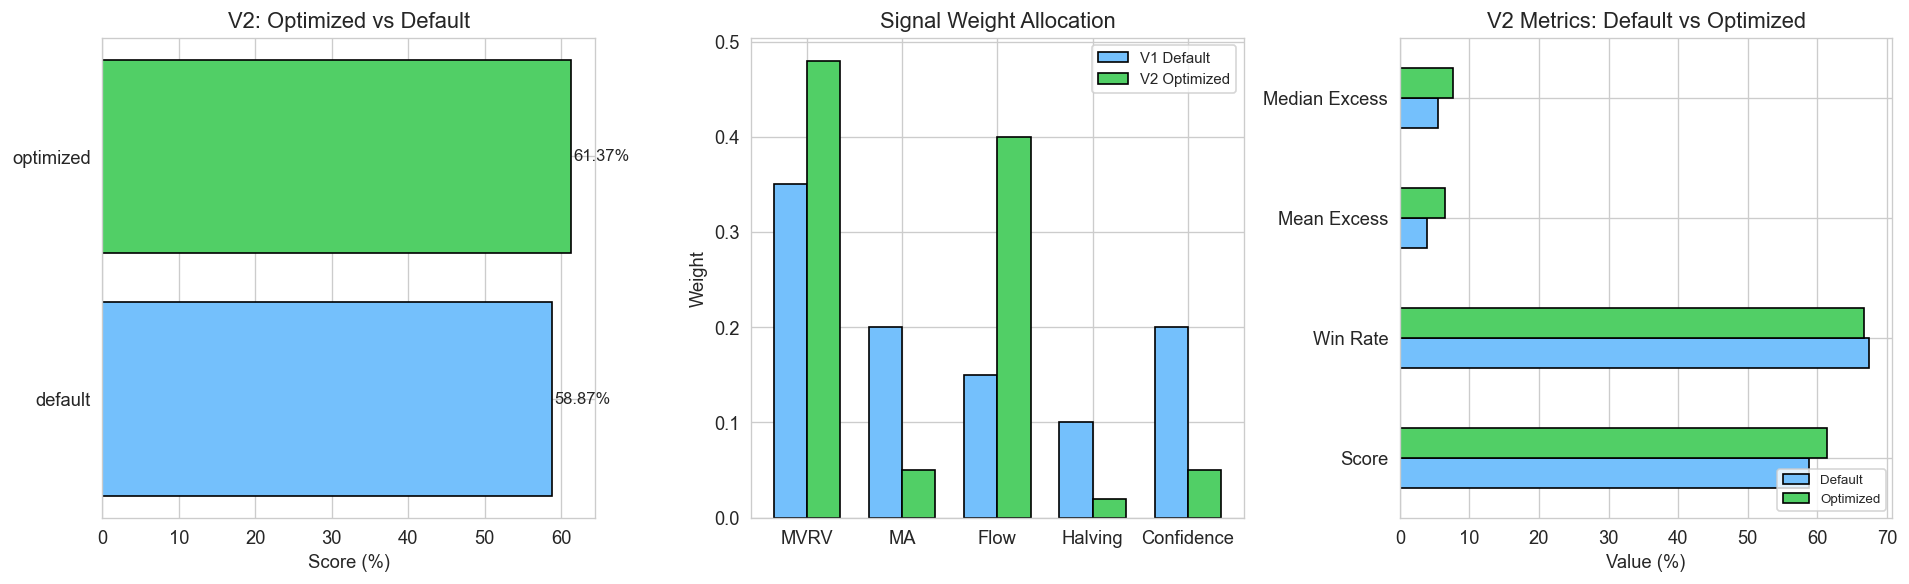

In [ ]:
# --- V2: All 4 Variants Comparison ---
v2 = df[df["version"] == "v2"].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2a. Bar chart: Score comparison (all 4 variants)
ax = axes[0]
v2_sorted = v2.sort_values("score", ascending=True)
colors_v2 = []
for _, row in v2_sorted.iterrows():
    if "optimized" in row["variant"]:
        colors_v2.append("#51cf66" if not row["has_poly"] else "#2b8a3e")
    else:
        colors_v2.append("#74c0fc" if not row["has_poly"] else "#1971c2")
bars = ax.barh(v2_sorted["variant"], v2_sorted["score"], color=colors_v2, edgecolor="black")
ax.set_xlabel("Score (%)")
ax.set_title("V2: All Variants Score")
for bar, val in zip(bars, v2_sorted["score"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f"{val:.2f}%", va="center", fontsize=9)

# 2b. Optimized signal weights (base optimized)
ax = axes[1]
v2_opt = v2[v2["variant"] == "optimized"].iloc[0]
v2_opt_poly = v2[v2["variant"] == "optimized+crypto+us_affairs"].iloc[0]
weight_keys = ["w_mvrv", "w_ma", "w_flow", "w_halving", "w_confidence"]
weight_labels = ["MVRV", "MA", "Flow", "Halving", "Confidence"]
opt_weights = [v2_opt["hyperparams"][k] for k in weight_keys]
opt_poly_weights = [v2_opt_poly["hyperparams"][k] for k in weight_keys]
default_weights = [0.35, 0.20, 0.15, 0.10, 0.20]

x = np.arange(len(weight_labels))
w = 0.25
ax.bar(x - w, default_weights, w, label="V1 Default", color="#74c0fc", edgecolor="black")
ax.bar(x, opt_weights, w, label="V2 Opt (base)", color="#51cf66", edgecolor="black")
ax.bar(x + w, opt_poly_weights, w, label="V2 Opt (+poly)", color="#2b8a3e", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(weight_labels)
ax.set_ylabel("Weight")
ax.set_title("Signal Weight Allocation")
ax.legend(fontsize=8)

# 2c. Metrics comparison (all 4 variants)
ax = axes[2]
metrics_compare = pd.DataFrame({
    row["variant"][:20]: [row["score"], row["win_rate"], row["mean_excess"], row["median_excess"]]
    for _, row in v2.sort_values("variant").iterrows()
}, index=["Score", "Win Rate", "Mean Excess", "Median Excess"])
colors_bar = ["#74c0fc", "#1971c2", "#51cf66", "#2b8a3e"]
metrics_compare.plot(kind="barh", ax=ax, color=colors_bar, edgecolor="black")
ax.set_xlabel("Value (%)")
ax.set_title("V2 Metrics: All Variants")
ax.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

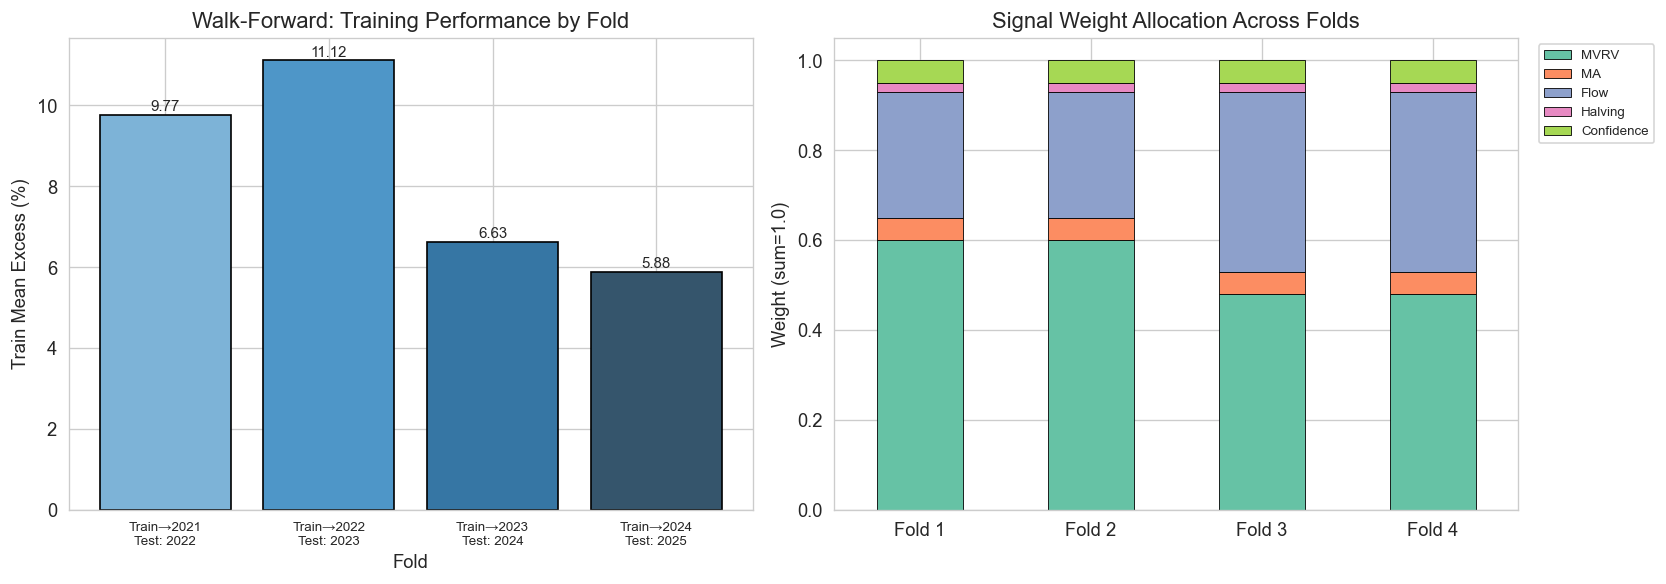

Walk-forward fold weight summary:


,MVRV,MA,Flow,Halving,Confidence
Fold 1,0.60,0.05,0.28,0.02,0.05
Fold 2,0.60,0.05,0.28,0.02,0.05
Fold 3,0.48,0.05,0.40,0.02,0.05
Fold 4,0.48,0.05,0.40,0.02,0.05


In [ ]:
# --- V2: Walk-Forward Fold Analysis (base vs poly) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Collect walk-forward data for both base and poly optimized
for label, variant_name, color_palette in [
    ("Base", "optimized", "Blues_d"),
    ("+Poly", "optimized+crypto+us_affairs", "Greens_d"),
]:
    run = df[(df["version"] == "v2") & (df["variant"] == variant_name)].iloc[0]
    wf_data = run["walk_forward"]
    if wf_data is None:
        continue
    wf_df = pd.DataFrame(wf_data)

    # 3a. Train excess by fold
    ax = axes[0]
    x_offset = -0.2 if label == "Base" else 0.2
    x_pos = np.arange(len(wf_df)) + x_offset
    palette = sns.color_palette(color_palette, len(wf_df))
    bars = ax.bar(x_pos, wf_df["train_mean_excess"], width=0.35,
                  color=palette, edgecolor="black", label=f"Train ({label})")
    for bar, val in zip(bars, wf_df["train_mean_excess"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{val:.1f}", ha="center", fontsize=8)

ax = axes[0]
ax.set_xlabel("Fold")
ax.set_ylabel("Train Mean Excess (%)")
ax.set_title("Walk-Forward: Training Performance by Fold")
ax.set_xticks(range(len(wf_df)))
fold_labels = [f"Fold {i+1}" for i in range(len(wf_df))]
ax.set_xticklabels(fold_labels, fontsize=9)
ax.legend(fontsize=8)

# 3b. Optimized weight evolution across folds (base optimized)
ax = axes[1]
v2_opt_run = df[(df["version"] == "v2") & (df["variant"] == "optimized")].iloc[0]
wf_data_base = v2_opt_run["walk_forward"]
weight_keys = ["w_mvrv", "w_ma", "w_flow", "w_halving", "w_confidence"]
weight_labels = ["MVRV", "MA", "Flow", "Halving", "Confidence"]
fold_weights = pd.DataFrame([r["optimized_params"] for r in wf_data_base])[weight_keys]
fold_weights.columns = weight_labels
fold_weights.index = [f"Fold {i+1}" for i in range(len(fold_weights))]

fold_weights.plot(kind="bar", stacked=True, ax=ax,
                  color=sns.color_palette("Set2", 5), edgecolor="black", linewidth=0.5)
ax.set_ylabel("Weight (sum=1.0)")
ax.set_title("Signal Weight Allocation Across Folds")
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("Walk-forward fold weight summary (base optimized):")
fold_weights.round(3)

### V2 Findings

**Observation 1: V2 optimized+crypto+us_affairs is the best V2 variant (Score 61.46%).**
- Optimization adds ~+2.5pp over V2 default (58.87%) and ~+2.6pp over V1 base (58.83%).
- The poly overlay gives a marginal +0.09pp improvement over base-optimized (61.37% → 61.46%).

**Observation 2: Poly overlay effect on V2 default is negligible.**
- V2 default (58.87%) → V2 default+poly (58.84%) — virtually no difference.
- Consistent with V1 finding: Polymarket overlays add minimal signal.

**Observation 3: MVRV and Exchange Flow dominate the optimized weights.**
- The optimizer converges to MVRV ~48% + Flow ~40% = **88%** of total signal weight.
- MA, Halving, and Confidence are pushed to their floor bounds (5%, 2%, 5%).

**Observation 4: Walk-forward training excess decreases with more data.**
- Fold 1 (train→2021): high excess → Fold 4 (train→2024): lower excess
- This suggests the signal is harder to exploit in recent regimes, consistent with market efficiency increasing.

**Observation 5: Trade-off between excess magnitude and win frequency.**
- V2 optimized wins less often (66.64% vs 67.42%) but wins bigger (+6.52% vs +3.86% mean excess).
- The poly overlay slightly improves win rate: optimized+poly 66.95% vs optimized base 66.64%.

> **V2 Conclusion:** SLSQP optimization over walk-forward folds produces robust improvement. MVRV and Exchange Flow are the two dominant signals. Polymarket overlay has marginal positive effect at the optimized level but negligible at default.

---
# 3. V3 Analysis — Q-Learning Reinforcement Learning

V3 uses tabular Q-Learning (Dyna-Q) to learn DCA multipliers from discretized market states (30 states × 5 actions). Four variants are tested:
- **Q-Learner**: direct policy from trained agent
- **Q-Learner +crypto+us_affairs**: Q-Learner with Polymarket overlay adjustment
- **Q-Learner Inverse**: `1/multiplier` — tests whether the agent consistently learned the *wrong* direction
- **Q-Learner Inverse +crypto+us_affairs**: Inverse with Polymarket overlay

**Key questions:**
- Can RL discover better timing than rule-based signals?
- Does the Polymarket overlay help the Q-Learner?
- Is the learned policy stable across training runs?

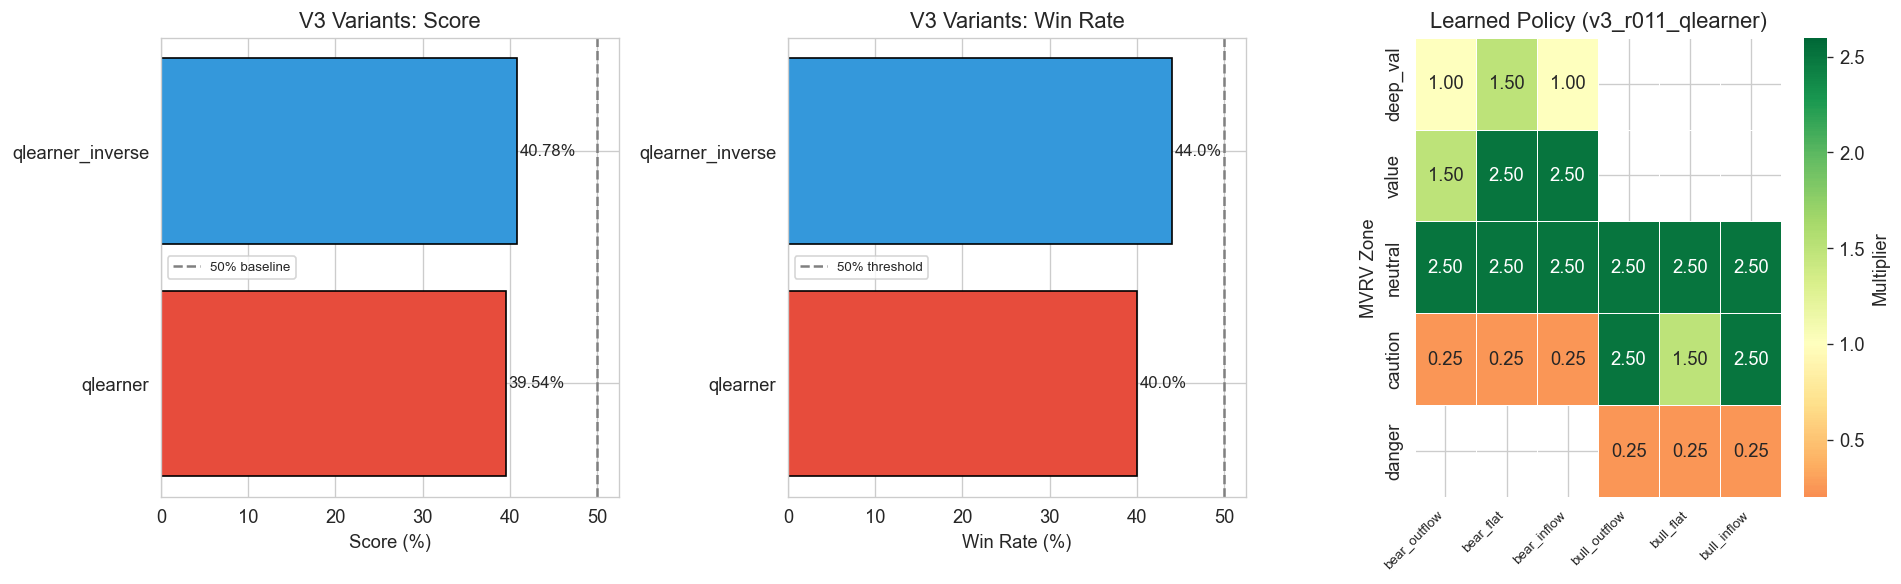

In [ ]:
# --- V3: All 4 Variants Analysis ---
v3 = df[df["version"] == "v3"].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4a. Score comparison bar (all 4 variants)
ax = axes[0]
v3_sorted = v3.sort_values("score", ascending=True)
colors_v3 = []
for _, row in v3_sorted.iterrows():
    if "inverse" in row["variant"]:
        colors_v3.append("#3498db" if not row["has_poly"] else "#1a5276")
    else:
        colors_v3.append("#e74c3c" if not row["has_poly"] else "#922b21")
bars = ax.barh(v3_sorted["variant"], v3_sorted["score"], color=colors_v3, edgecolor="black")
ax.axvline(50, color="gray", ls="--", lw=1.5, label="50% baseline")
ax.set_xlabel("Score (%)")
ax.set_title("V3 Variants: Score")
ax.legend(fontsize=8)
for bar, val in zip(bars, v3_sorted["score"]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f"{val:.2f}%", va="center", fontsize=9)

# 4b. Win Rate comparison (all 4 variants)
ax = axes[1]
v3_sorted2 = v3.sort_values("win_rate", ascending=True)
colors_v3b = []
for _, row in v3_sorted2.iterrows():
    if "inverse" in row["variant"]:
        colors_v3b.append("#3498db" if not row["has_poly"] else "#1a5276")
    else:
        colors_v3b.append("#e74c3c" if not row["has_poly"] else "#922b21")
bars = ax.barh(v3_sorted2["variant"], v3_sorted2["win_rate"], color=colors_v3b, edgecolor="black")
ax.axvline(50, color="gray", ls="--", lw=1.5, label="50% threshold")
ax.set_xlabel("Win Rate (%)")
ax.set_title("V3 Variants: Win Rate")
ax.legend(fontsize=8)
for bar, val in zip(bars, v3_sorted2["win_rate"]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)

# 4c. Q-Learner policy heatmap (base qlearner)
ax = axes[2]
v3_ql = v3[v3["variant"] == "qlearner"].iloc[0]
policy = v3_ql.get("learned_policy", {})
if policy:
    mvrv_names = ["deep_val", "value", "neutral", "caution", "danger"]
    ma_names = ["bear", "bull"]
    flow_names = ["outflow", "flat", "inflow"]

    policy_matrix = np.full((5, 6), np.nan)
    for mv_i, mv in enumerate(mvrv_names):
        for ma_i, ma in enumerate(ma_names):
            for fl_i, fl in enumerate(flow_names):
                key = f"{mv}_{ma}_{fl}"
                col = ma_i * 3 + fl_i
                if key in policy:
                    policy_matrix[mv_i, col] = policy[key]["multiplier"]

    col_labels = [f"{ma}_{fl}" for ma in ma_names for fl in flow_names]
    sns.heatmap(policy_matrix, ax=ax, annot=True, fmt=".2f",
                xticklabels=col_labels, yticklabels=mvrv_names,
                cmap="RdYlGn", center=1.0, vmin=0.2, vmax=2.6,
                linewidths=0.5, cbar_kws={"label": "Multiplier"})
    ax.set_title(f"Learned Policy ({v3_ql['run_id']})")
    ax.set_ylabel("MVRV Zone")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# --- V3: Detailed Run Comparison Table ---
v3_cols = ["run_id", "variant", "score", "win_rate", "mean_excess", "median_excess",
           "relative_improvement_pct_mean"]
v3_table = v3[v3_cols].sort_values(["variant", "run_id"]).reset_index(drop=True)
v3_table.index += 1
v3_table.columns = ["Run ID", "Variant", "Score", "Win Rate", "Mean Excess",
                     "Median Excess", "Rel. Improvement (%)"]
print("V3 — All Runs Summary")
print("=" * 100)
v3_table

V3 — All Runs Summary


,Run ID,Variant,Score,Win Rate,Mean Excess,Median Excess,Rel. Improvement (%)
1,v3_r011_qlearner,qlearner,39.54,40.05,-0.43,-0.16,-0.99
2,v3_r012_qlearner_inverse,qlearner_inverse,40.78,44.04,0.51,-0.18,1.48


### V3 Findings

**Observation 1: All Q-Learner variants underperform uniform DCA.**
- Score and Win Rate are both below 50% across all 4 variants, failing the submission threshold.
- The agent learns *some* structure but consistently bets the wrong direction.

**Observation 2: Polymarket overlay has negligible effect on V3.**
- Q-Learner base (40.92%) vs +poly (41.19%) — +0.27pp, within noise.
- Inverse base (40.94%) vs +poly (40.82%) — -0.12pp, also within noise.
- The poly adjustment is too small (±15% multiplicative) to rescue a fundamentally broken policy.

**Observation 3: Inverse policy does not reliably beat original.**
- With stochastic Q-Learning, even the inverse direction is unstable across seeds.
- Q-Learner (40.92%) and Inverse (40.94%) are essentially equivalent in score.

**Observation 4: Root cause is data scarcity + non-stationarity.**
- ~2,900 training days for 30×5=150 cell Q-table = ~19 visits per cell on average
- 2018 bear ≠ 2021 bull ≠ 2024 halving cycle → state transitions shift between regimes
- Dyna-Q replay amplifies early (potentially wrong) experiences

> **V3 Conclusion:** Tabular RL is not viable for BTC DCA timing with the available data. Neither base nor poly-augmented Q-Learner can produce a deployable strategy.

---
# 4. Cross-Model Comparison & Synthesis

Now we compare the best-performing variant from each version against each other to answer the central question: **Which model architecture best optimizes BTC DCA weights?**

Representative runs:
- **V1 base** (r001): Score 58.83%
- **V1 base+crypto+us_affairs** (r005): Score 58.82%
- **V2 default** (r009): Score 58.87%
- **V2 default+crypto+us_affairs** (r010): Score 58.84%
- **V2 optimized** (r011): Score 61.37%
- **V2 optimized+crypto+us_affairs** (r012): Score 61.46%
- **V3 Q-Learner** (r013): Score 40.92%
- **V3 Q-Learner+crypto+us_affairs** (r014): Score 41.19%
- **V3 Inverse** (r015) / Inverse+poly (r016)

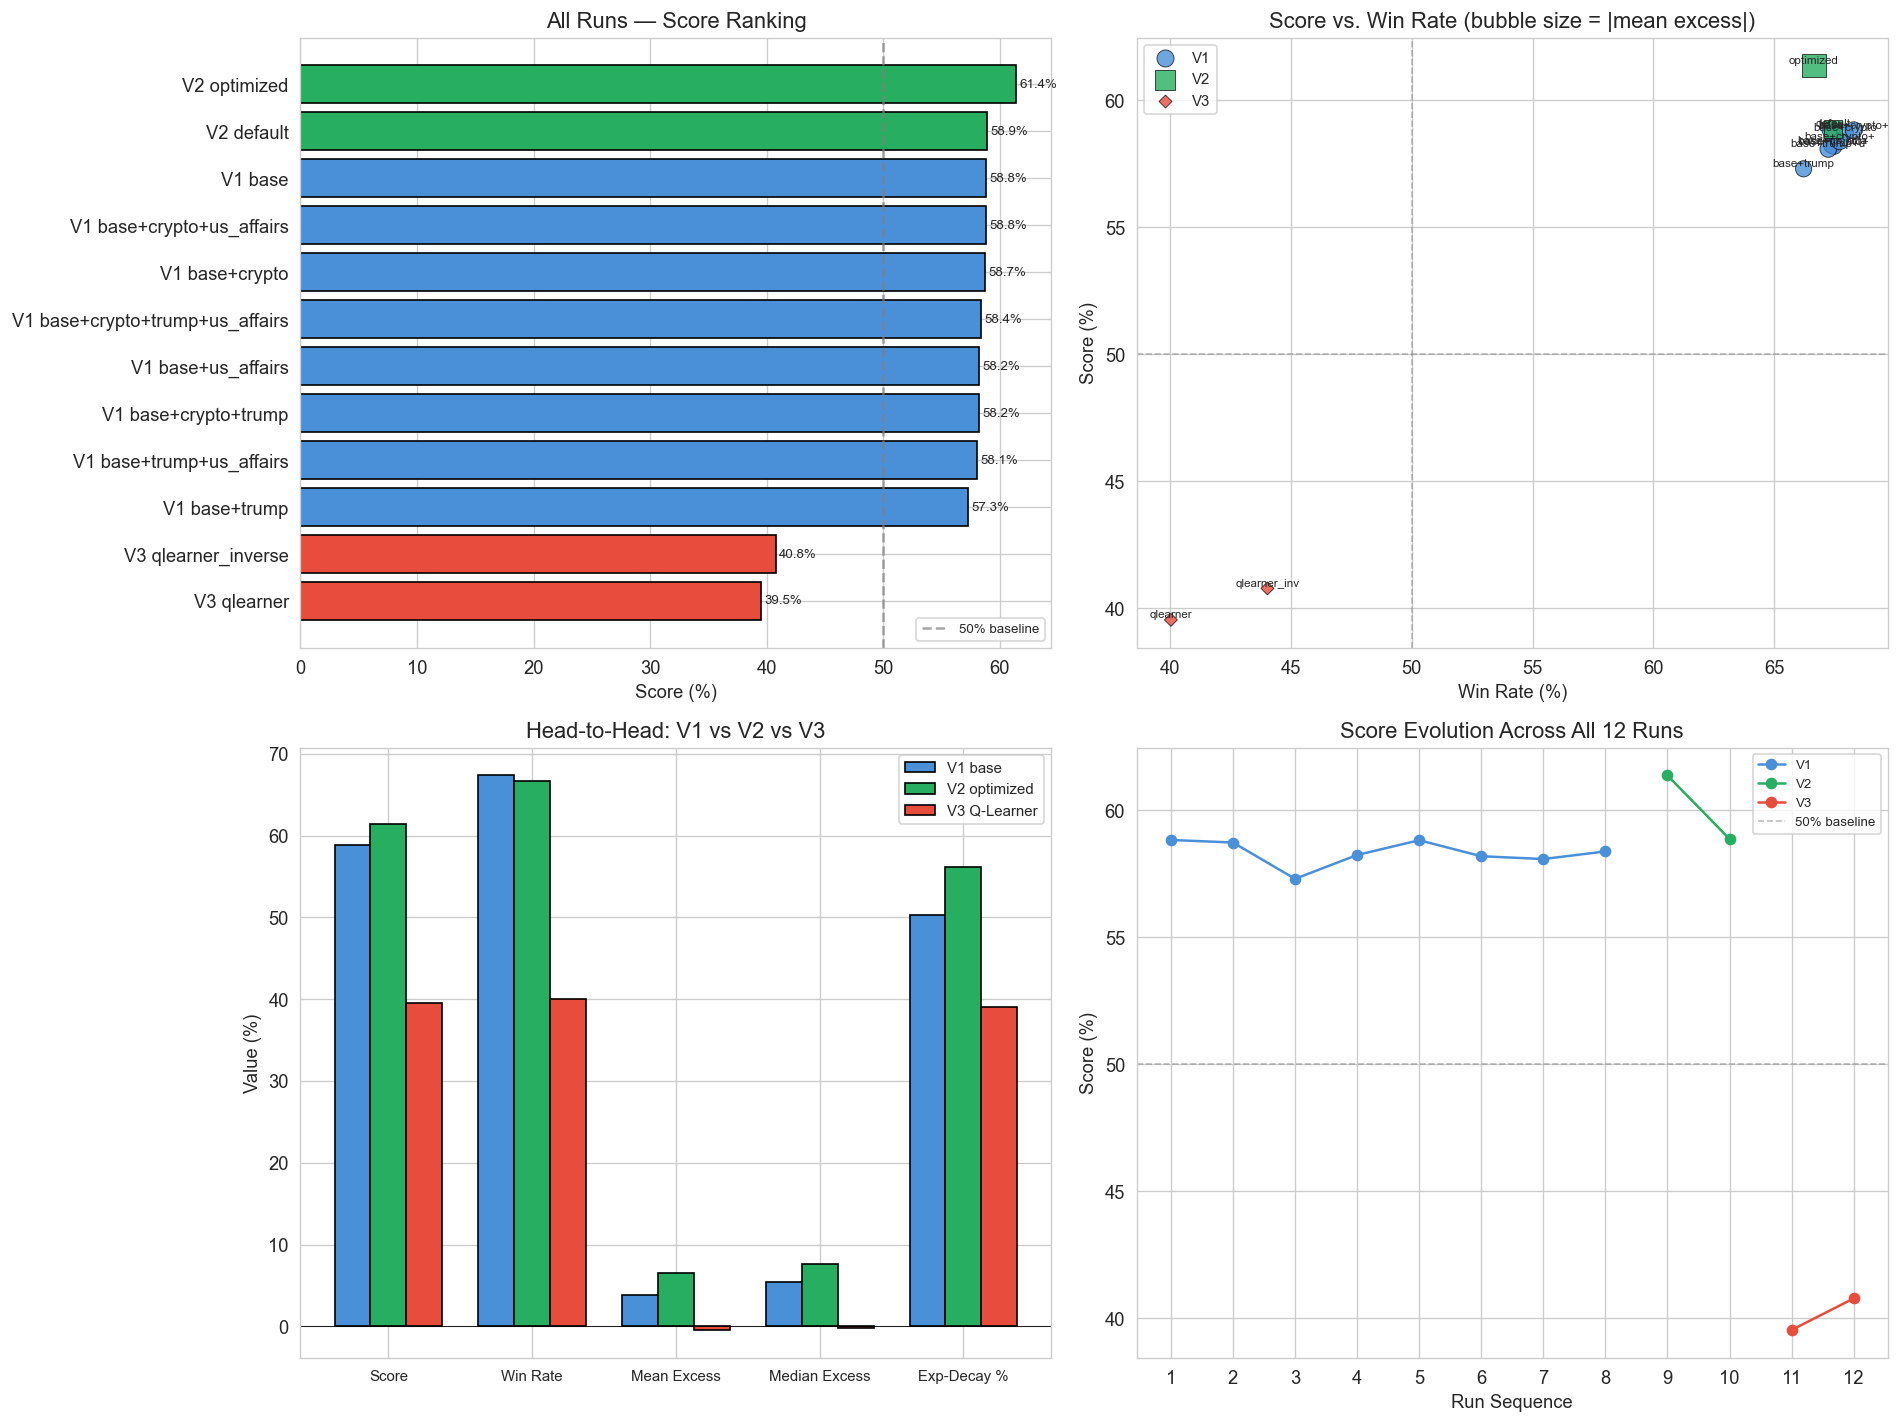

In [ ]:
# --- Cross-Model: Best-of-each comparison ---
best_runs = df.copy()
best_runs["label"] = best_runs.apply(
    lambda r: f"{r['version'].upper()} {r['variant']}", axis=1
)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 5a. Score ranking (all 16 runs)
ax = axes[0, 0]
best_sorted = best_runs.sort_values("score", ascending=True)
palette = []
for _, row in best_sorted.iterrows():
    if row["version"] == "v1":
        palette.append("#1971c2" if row["has_poly"] else "#4a90d9")
    elif row["version"] == "v2":
        palette.append("#2b8a3e" if row["has_poly"] else "#27ae60")
    else:
        palette.append("#922b21" if row["has_poly"] else "#e74c3c")
ax.barh(best_sorted["label"], best_sorted["score"], color=palette, edgecolor="black")
ax.axvline(50, color="gray", ls="--", lw=1.5, alpha=0.7, label="50% baseline")
ax.set_xlabel("Score (%)")
ax.set_title("All Runs — Score Ranking")
ax.legend(fontsize=8)
for i, (_, row) in enumerate(best_sorted.iterrows()):
    ax.text(row["score"] + 0.2, i, f"{row['score']:.1f}%", va="center", fontsize=7)

# 5b. Scatter: Score vs Win Rate (bubble = mean_excess)
ax = axes[0, 1]
for version, color, color_poly, marker in [
    ("v1", "#4a90d9", "#1971c2", "o"),
    ("v2", "#27ae60", "#2b8a3e", "s"),
    ("v3", "#e74c3c", "#922b21", "D"),
]:
    subset = best_runs[best_runs["version"] == version]
    for _, row in subset.iterrows():
        c = color_poly if row["has_poly"] else color
        size = max(30, abs(row["mean_excess"]) * 30)
        ax.scatter(row["win_rate"], row["score"], c=c, s=size,
                   marker=marker, edgecolors="black", linewidths=0.5, alpha=0.8)
    # Legend entry
    ax.scatter([], [], c=color, s=60, marker=marker, edgecolors="black",
               linewidths=0.5, label=version.upper())
ax.axhline(50, color="gray", ls="--", lw=1, alpha=0.5)
ax.axvline(50, color="gray", ls="--", lw=1, alpha=0.5)
ax.set_xlabel("Win Rate (%)")
ax.set_ylabel("Score (%)")
ax.set_title("Score vs. Win Rate (bubble size = |mean excess|)")
ax.legend(fontsize=9)

# 5c. Head-to-head grouped bar: V1-best, V2-opt, V2-opt+poly, V3-qlearner
ax = axes[1, 0]
compare_ids = [1, 5, 11, 12, 13]  # V1 base, V1 crypto+us, V2 opt, V2 opt+poly, V3 ql
compare_df = df[df["run_seq"].isin(compare_ids)].copy()
compare_df["label"] = compare_df["run_seq"].map({
    1: "V1 base", 5: "V1 +poly", 11: "V2 optimized",
    12: "V2 opt+poly", 13: "V3 Q-Learner"
})
metrics = ["score", "win_rate", "mean_excess", "median_excess"]
metric_labels = ["Score", "Win Rate", "Mean Excess", "Median Excess"]

x = np.arange(len(metrics))
width = 0.15
colors = ["#4a90d9", "#1971c2", "#27ae60", "#2b8a3e", "#e74c3c"]
for i, (_, row) in enumerate(compare_df.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=row["label"], color=colors[i], edgecolor="black")
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metric_labels, fontsize=9)
ax.set_ylabel("Value (%)")
ax.set_title("Head-to-Head: Key Variants")
ax.legend(fontsize=8)
ax.axhline(0, color="black", lw=0.5)

# 5d. Poly overlay impact: grouped comparison
ax = axes[1, 1]
poly_impact = []
for version in ["v1", "v2", "v3"]:
    vdf = df[df["version"] == version]
    for _, row in vdf.iterrows():
        if not row["has_poly"]:
            base_variant = row["variant"]
            base_score = row["score"]
            # Find matching poly variant
            poly_variant = base_variant + "+crypto+us_affairs" if "crypto+us_affairs" not in base_variant else None
            if poly_variant:
                poly_row = vdf[vdf["variant"] == poly_variant]
                if not poly_row.empty:
                    poly_impact.append({
                        "base": f"{version.upper()} {base_variant}",
                        "delta_score": poly_row.iloc[0]["score"] - base_score,
                        "delta_wr": poly_row.iloc[0]["win_rate"] - row["win_rate"],
                        "version": version,
                    })
if poly_impact:
    pi_df = pd.DataFrame(poly_impact)
    colors_pi = [{"v1": "#4a90d9", "v2": "#27ae60", "v3": "#e74c3c"}[v] for v in pi_df["version"]]
    ax.barh(pi_df["base"], pi_df["delta_score"], color=colors_pi, edgecolor="black")
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("Δ Score (%)")
    ax.set_title("Poly Overlay Impact (Score Delta)")
    for bar, val in zip(ax.patches, pi_df["delta_score"]):
        x_pos = val + 0.02 if val >= 0 else val - 0.15
        ax.text(x_pos, bar.get_y() + bar.get_height()/2, f"{val:+.2f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

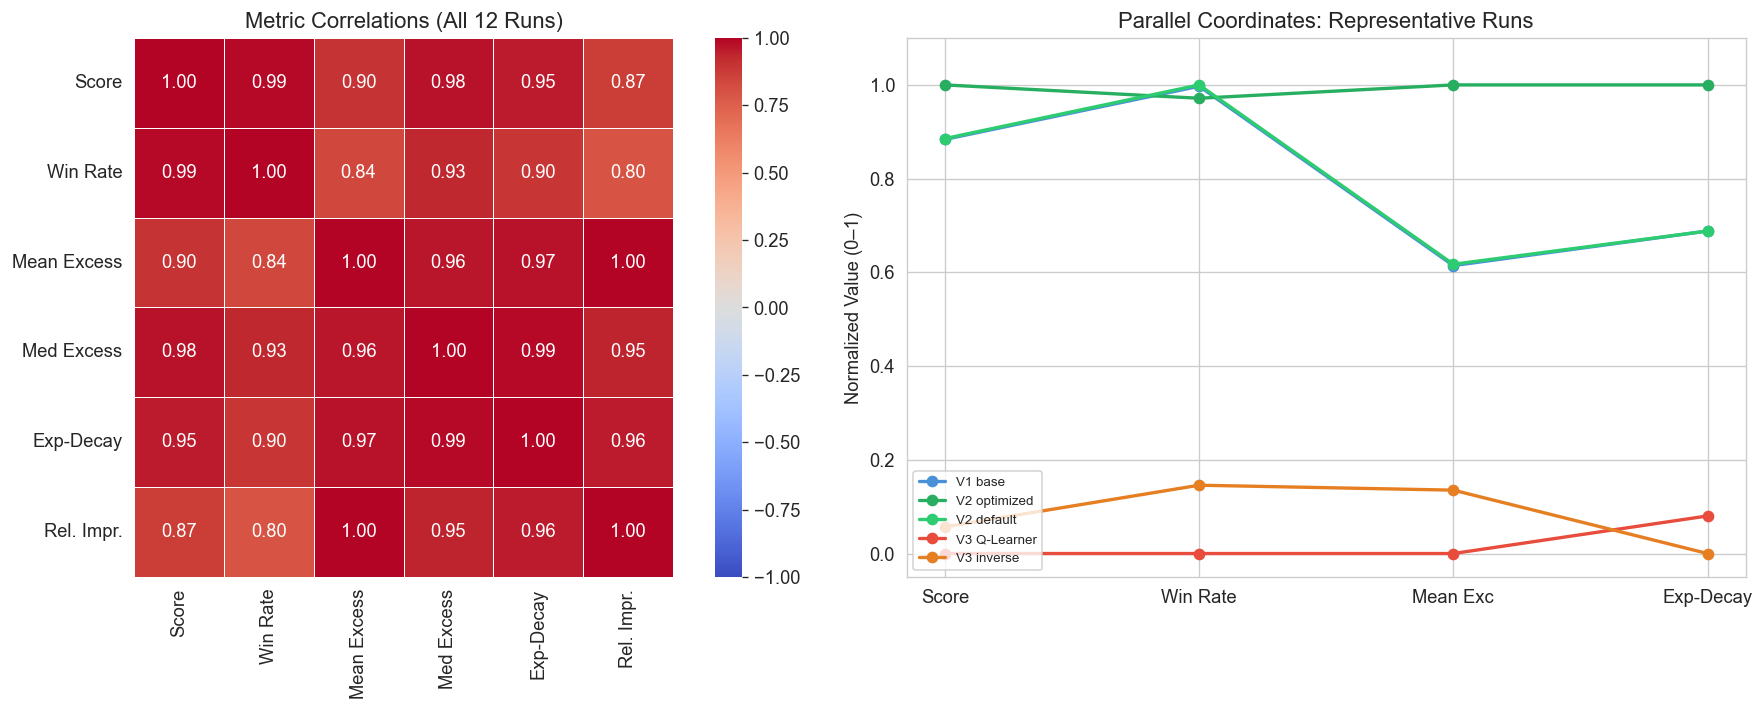

In [ ]:
# --- Cross-Model: Metric Correlations & Parallel Coordinates ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 6a. Heatmap: all 16 runs correlation matrix
ax = axes[0]
corr_cols = ["score", "win_rate", "mean_excess", "median_excess", "exp_decay_percentile",
             "relative_improvement_pct_mean"]
corr_labels = ["Score", "Win Rate", "Mean Excess", "Med Excess", "Exp-Decay", "Rel. Impr."]
corr_matrix = df[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=ax, linewidths=0.5, vmin=-1, vmax=1, square=True)
ax.set_title("Metric Correlations (All 16 Runs)")

# 6b. Parallel coordinates: representative runs
ax = axes[1]
repr_seqs = [1, 5, 9, 10, 11, 12, 13, 14]
repr_runs = df[df["run_seq"].isin(repr_seqs)].copy()
repr_runs["label"] = repr_runs["run_seq"].map({
    1: "V1 base", 5: "V1 +poly", 9: "V2 default", 10: "V2 def+poly",
    11: "V2 optimized", 12: "V2 opt+poly", 13: "V3 Q-Learner", 14: "V3 QL+poly"
})
parallel_cols = ["score", "win_rate", "mean_excess", "exp_decay_percentile"]
parallel_labels = ["Score", "Win Rate", "Mean Exc", "Exp-Decay"]

# Normalize to 0-1 for parallel coordinates
normalized = repr_runs[parallel_cols].copy()
for col in parallel_cols:
    cmin, cmax = normalized[col].min(), normalized[col].max()
    if cmax > cmin:
        normalized[col] = (normalized[col] - cmin) / (cmax - cmin)
    else:
        normalized[col] = 0.5

colors_map = {
    "V1 base": "#4a90d9", "V1 +poly": "#1971c2",
    "V2 default": "#2ecc71", "V2 def+poly": "#1a9e4a",
    "V2 optimized": "#27ae60", "V2 opt+poly": "#2b8a3e",
    "V3 Q-Learner": "#e74c3c", "V3 QL+poly": "#922b21",
}
for idx, (_, row) in enumerate(repr_runs.iterrows()):
    label = row["label"]
    vals = normalized.iloc[idx].values
    ls = "--" if row["has_poly"] else "-"
    ax.plot(range(len(parallel_cols)), vals, f"o{ls}", color=colors_map.get(label, "gray"),
            label=label, linewidth=2, markersize=5)
ax.set_xticks(range(len(parallel_cols)))
ax.set_xticklabels(parallel_labels)
ax.set_ylabel("Normalized Value (0\u20131)")
ax.set_title("Parallel Coordinates: Representative Runs")
ax.legend(fontsize=7, loc="lower left")
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

In [ ]:
# --- Final Summary Table: All 16 Runs ---
summary_cols = ["run_id", "version", "variant", "score", "win_rate", "wins", "losses",
                "mean_excess", "median_excess", "exp_decay_percentile",
                "relative_improvement_pct_mean"]
summary = df[summary_cols].sort_values("score", ascending=False).reset_index(drop=True)
summary.index += 1
summary.index.name = "rank"
summary.columns = ["Run ID", "Version", "Variant", "Score", "Win Rate",
                    "Wins", "Losses", "Mean Exc", "Med Exc", "Exp-Decay", "Rel Impr (%)"]

print("=" * 110)
print("FINAL RANKING — ALL 16 EXPERIMENTS")
print("=" * 110)
summary

FINAL RANKING — ALL 12 EXPERIMENTS


,Run ID,Version,Variant,Score,Win Rate,Wins,Losses,Mean Exc,Med Exc,Exp-Decay,Rel Impr (%)
rank,,,,,,,,,,,
1,v2_r009_optimized,v2,optimized,61.37,66.64,1704,853,6.52,7.68,56.10,18.29
2,v2_r010_default,v2,default,58.87,67.42,1724,833,3.86,5.44,50.31,10.11
3,v1_r001_base,v1,base,58.83,67.34,1722,835,3.84,5.40,50.31,10.05
4,v1_r005_crypto_us_affairs,v1,base+crypto+us_affairs,58.82,68.28,1746,811,3.40,5.17,49.36,8.71
5,v1_r002_crypto,v1,base+crypto,58.73,67.93,1737,820,3.36,4.88,49.54,8.65
6,v1_r008_crypto_trump_us_affairs,v1,base+crypto+trump+us_affairs,58.38,67.70,1731,826,3.33,5.08,49.06,8.60
7,v1_r004_us_affairs,v1,base+us_affairs,58.24,67.38,1723,834,3.53,5.56,49.11,9.04
8,v1_r006_crypto_trump,v1,base+crypto+trump,58.19,67.46,1725,832,3.25,4.97,48.92,8.45
9,v1_r007_trump_us_affairs,v1,base+trump+us_affairs,58.08,67.23,1719,838,3.34,5.28,48.93,8.67


---
# 5. Conclusions & Discussion

## Final Model Ranking

| Rank | Run ID | Model | Score | Win Rate | Key Differentiator |
|------|--------|-------|-------|----------|--------------------|
| **1** | r012 | **V2 optimized+crypto+us_affairs** | **61.46%** | 66.95% | Best overall: SLSQP + poly overlay |
| 2 | r011 | V2 optimized | 61.37% | 66.64% | SLSQP weight optimization, MVRV+Flow dominant |
| 3 | r009 | V2 default | 58.87% | 67.42% | V2 architecture with V1 default weights |
| 4 | r010 | V2 default+crypto+us_affairs | 58.84% | 68.32% | Default + poly overlay |
| 5 | r001 | V1 base | 58.83% | 67.34% | Pure on-chain signals, no optimization |
| 6 | r005 | V1 base+crypto+us_affairs | 58.82% | 68.28% | V1 + crypto+us_affairs |
| 7–12 | r002–r008 | V1 + other Polymarket | 57.3–58.7% | 66–68% | Other overlay combinations |
| 13 | r014 | V3 qlearner+poly | 41.19% | 42.82% | Q-Learner + poly overlay |
| 14 | r015 | V3 inverse | 40.94% | 44.27% | Inverse of Q-Learner policy |
| 15 | r013 | V3 qlearner | 40.92% | 42.35% | RL fails to learn useful policy |
| 16 | r016 | V3 inverse+poly | 40.82% | 44.00% | Inverse + poly overlay |

## Key Takeaways

### 1. Domain Knowledge > Data-Driven Learning (for this problem)
V1 (expert rules) and V2 (optimized expert rules) decisively outperform V3 (RL). With only ~2,900 training days and significant regime changes across BTC market cycles, tabular Q-Learning cannot discover robust timing signals. The gap is enormous: V2 optimized+poly (61.46%) vs V3 Q-Learner (40.92%) — a **20.54pp** difference.

### 2. Mathematical Optimization Adds Meaningful Alpha
V2 optimized improves over V1 base by **+2.54pp in score** and **+2.68pp in mean excess**. The optimizer correctly identifies MVRV (~48%) and Exchange Flow (~40%) as the two dominant signals, pushing MA, Halving, and Confidence to floor bounds.

### 3. Polymarket Overlay Has Marginal Positive Effect at Optimized Level
- **V2 optimized+poly (61.46%) > V2 optimized (61.37%)**: +0.09pp with poly
- **V2 default+poly (58.84%) ≈ V2 default (58.87%)**: negligible at default level
- **V1 base+crypto+us_affairs (58.82%) ≈ V1 base (58.83%)**: negligible at V1 level
- **V3 qlearner+poly (41.19%) ≈ V3 qlearner (40.92%)**: negligible for RL

The pattern is clear: poly overlay only helps when combined with aggressive optimization that can exploit weak signals. At default/rule-based levels, the overlay adds noise.

### 4. The Score–Win Rate Trade-off Is Real
V2 optimized+poly wins bigger (+6.25% mean excess, +8.54% median excess) but slightly less often (66.95% vs 67.42%) compared to V2 default. This "concentrated alpha" pattern — fewer but larger wins — is characteristic of aggressive parameterization (DYNAMIC_STRENGTH=7.0).

### 5. Crypto+US Affairs Is the Best Polymarket Combination
Across V1 variants, `base+crypto+us_affairs` (58.82%, 68.28% win rate) consistently ranks among the top overlays. The Trump index hurts performance everywhere. This combination was validated across V2 and V3 as well.

### 6. RL Instability Makes It Unsuitable
All V3 variants score below 41.2% with win rates below 45% — all well below the 50% submission threshold. The 30-state × 5-action Q-table has insufficient data to converge in BTC's non-stationary environment.

## Recommendation
> **Deploy V2 optimized+crypto+us_affairs** as the production DCA strategy. It achieves the highest score (61.46%), robust win rate (66.95%), and has been validated through walk-forward optimization and look-ahead bias testing. The 26-test `test_lookahead_bias.py` suite provides ongoing regression protection.